# LOAD DATA FIRST

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

homedir = "/Users/morpholino/ownCloud/"
#homedir = "/Volumes/zoliq data/ownCloud/"
wd = homedir + "Jankoviny/Tick_transcriptome/klastrovani/normalizace_19-12-16"
os.chdir(wd)
#print([f for f in os.listdir()])

array = {}
indices = ['egg', 'larvae', 'fednymph', 'female', 'fedfemale']

print("loading data...")
"""
with open("kliste_norm_hierch_kmean_rada.gct") as f: #"trans.sample.gene-count_sorted.matrix.TMM.EXPR.txt" for the entire set
    c = 0
    for l in f:
        if c == 2:
            c += 1
            allcolumns = l.strip().split("\t")[1:]
            allcolumns = [x.replace(".RSEM","") for x in allcolumns]
            print("identified columns:")
            print(allcolumns)
        elif c < 3:
            c += 1
            print("ignored:" + l.strip())
        else:
            data = l.strip().split("\t")
            array[data[0]] = [float(x) for x in data[1:]]
print("reading morpheus infile finished")
#first, identify the most variable contigs
df = pd.DataFrame(array, index=allcolumns, dtype=np.float64)

X = df.T
Xsub = X[indices]
"""
#read pickled data prepared by assign_cluster.py:
read_from_pickle = True
if read_from_pickle:
    X = pd.read_pickle("kliste_matice_klastry.pkl")
    allcolumns = list(X.columns)
    print("identified columns:")
    print(", ".join(allcolumns))
    Xsub = X[indices]
else:
    print("failed")


print("\nCONTINUE WITH FURTHER ANALYSES")

loading data...
identified columns:
dendro_10, dendro_11, dendro_12, dendro_13, dendro_15, dendro_17, dendro_19, dendro_23, dendro_25, dendro_27, dendro_31, dendro_36, dendro_4, dendro_42, dendro_50, dendro_6, dendro_7, dendro_9, k_means_2, k_means_3, k_means_5, k_means_7, k_means_9, k_means_11, k_means_13, k_means_10, k_means_15, k_means_17, k_means_20, k_means_23, k_means_26, k_means_30, k_means_35, k_means_40, k_means_50, egg, larvae, fednymph, female, fedfemale

CONTINUE WITH FURTHER ANALYSES


# calculate and plot the top 1000 variable genes

In [6]:
print("computing variance for all contigs...")
variance = np.var(Xsub, axis=1)
sortedvar = variance.sort_values(ascending=False, inplace=False)
topthousand = sortedvar.head(1000)

print("filtering subarray of contigs with highest variance")
x = [1, 2, 3, 4, 5]
subarray = {k:array[k][-5:] for k in array.keys() if k in list(topthousand.index)}
y = pd.DataFrame(subarray, index=indices, dtype=np.float64)
#print(y)

print("filtering contigs with highest variance finished")
print("CONTINUE TO WRITE OUTPUT FILES")

computing variance for all contigs...
filtering subarray of contigs with highest variance
filtering contigs with highest variance finished
CONTINUE TO WRITE OUTPUT FILES


writing most variable contigs to table
plotting data


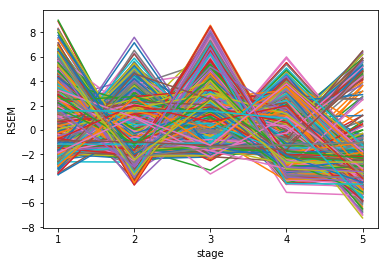

In [7]:
print("writing most variable contigs to table")
with open("top1000.tsv","w") as out:
    out.write("contig\t{}\n".format("\t".join(indices)))
    for seq in list(topthousand.index):
        #print(seq, topthousand[seq]) #and this is how you extract the respective values
        data = [str(x).replace(".",",") for x in array[seq][-5:]] #index important to extract only the stage RSEMs
        data = "\t".join(data)
        out.write("{}\t{}\n".format(seq, data))

print("plotting data")
labels = indices
plt.style.context('Solarize_Light2')
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set(xlabel="stage", ylabel="RSEM")
ax.set_xticks(x)
fig.savefig("variances.png")
plt.show()

# this section is to calculate per-module variance, centroid and plot average expression and STD across stages. 
#this is irrelevant for the new normalized data


In [14]:
#here i need to calculate the standardized expressions:
Xstd = X.loc[:, "egg":"fedfemale"].add(1)
Xstd['mean'] = Xstd.loc[:,"egg":"fedfemale"].mean(axis=1)
#X['mean'] = X.loc[:,"egg":"fedfemale"].mean(axis=1)
#X['eggstd'] = X.loc[:,"egg"].replace(0, 0.01)
stages = ['egg', 'larvae', 'fednymph', 'female', 'fedfemale']
for stage in stages:
    std = Xstd['egg']
    # or standardize to mean: 
    #std = X['mean']
    Xstd[stage + "_n"] = np.log(Xstd.loc[:,stage]/std) 
#print(X.head(10))
Xsub = Xstd.loc[:,"egg_n":"fedfemale_n"] #note that the original RSEM data were "discarded"
print(Xsub.head(10))

           egg_n  larvae_n  fednymph_n  female_n  fedfemale_n
c69487_g1    0.0 -0.138643   -1.720976 -0.568252    -0.685131
c81483_g2    0.0  0.784358    0.000000  0.000000     0.708036
c84188_g3    0.0  0.457744    0.784666 -0.030019     0.180468
c75238_g6    0.0  0.595969   -0.191092  0.131769    -0.350657
c79769_g3    0.0  1.260463    1.240580  1.418056     2.170419
c86459_g1    0.0  0.000000    1.995924  0.000000     0.000000
c63343_g1    0.0  0.019719   -0.340749  0.052644     0.263021
c65732_g1    0.0 -0.253095   -0.571462  0.512989    -0.462560
c52513_g2    0.0 -1.019930   -1.019930 -1.019930    -1.019930
c77867_g1    0.0 -0.769113   -0.699958 -0.568517    -0.846042


In [15]:
print(Xstd.loc[:, "egg":].head(10))
print(X.loc[:, "egg":].head(10))

              egg  larvae  fednymph  female  fedfemale     mean  egg_n  \
c69487_g1  13.170  11.465     2.356   7.461      6.638   8.2180    0.0   
c81483_g2   1.000   2.191     1.000   1.000      2.030   1.4442    0.0   
c84188_g3   6.391  10.101    14.007   6.202      7.655   8.8712    0.0   
c75238_g6   1.420   2.577     1.173   1.620      1.000   1.5580    0.0   
c79769_g3   5.415  19.099    18.723  22.359     47.446  22.6084    0.0   
c86459_g1   1.000   1.000     7.359   1.000      1.000   2.2718    0.0   
c63343_g1   1.406   1.434     1.000   1.482      1.829   1.4302    0.0   
c65732_g1   1.847   1.434     1.043   3.085      1.163   1.7144    0.0   
c52513_g2   2.773   1.000     1.000   1.000      1.000   1.3546    0.0   
c77867_g1   2.652   1.229     1.317   1.502      1.138   1.5676    0.0   

           larvae_n  fednymph_n  female_n  fedfemale_n  
c69487_g1 -0.138643   -1.720976 -0.568252    -0.685131  
c81483_g2  0.784358    0.000000  0.000000     0.708036  
c84188_g3  0.4

In [96]:
#calculate variance for standardized data
variance = np.var(X.loc[:,"egg":"fedfemale"], axis=1)
sortedvar = variance.sort_values(ascending=0, inplace=False)
topthousand = sortedvar.head(1000)

variance_n = np.var(X.loc[:,"egg_n":"fedfemale_n"], axis=1) #limits calculation to columns defined after the comma
sortedvar_n = variance_n.sort_values(ascending=0, inplace=False)
topthousand_n = sortedvar_n.head(1000)

#list(topthousand_n.index)[:5] #this is how you extract indices from a np.series
print("filtering subarray of contigs with highest variance")
x = [1, 2, 3, 4, 5]
subarray = {k:array[k][-5:] for k in array.keys() if k in list(topthousand.index)} 
y = pd.DataFrame(subarray, index=indices, dtype=np.float64)
#and also normalized:
topstuff = [k for k in list(Xsub.index) if k in list(topthousand.index)]
topvariablenorm = Xsub.filter(items=topstuff, axis=0) #specify axis to filter indexes not values
y_n = pd.DataFrame(topvariablenorm.T, dtype=np.float64)
print(y.T.head(5))
print(y_n.T.head(5))

print("filtering contigs with highest variance finished")
print("CONTINUE TO WRITE OUTPUT FILES")

filtering subarray of contigs with highest variance
               egg   larvae  fednymph   female  fedfemale
c1059_g1      0.11     0.00      0.94     0.14     212.45
c10799_g1  2751.61  3756.10   2379.60  4365.15    2212.77
c10833_g1     0.19    31.70    244.95    42.17     559.12
c10837_g1   654.03   100.34     66.00   182.30      78.65
c10838_g1  2525.65  2710.08   3173.85  3726.99    2290.49
             egg_n  larvae_n  fednymph_n  female_n  fedfemale_n
c1059_g1   0.00995 -4.605170    2.146569  0.248988     7.565987
c10799_g1  0.00995  0.318494   -0.133757  0.467750    -0.205583
c10833_g1  0.00995  5.117108    7.161793  5.402485     7.987099
c10837_g1  0.00995 -1.811444   -2.199011 -1.242252    -2.038266
c10838_g1  0.00995  0.079756    0.236373  0.395856    -0.086766
filtering contigs with highest variance finished
CONTINUE TO WRITE OUTPUT FILES


writing most variable contigs to table
plotting data


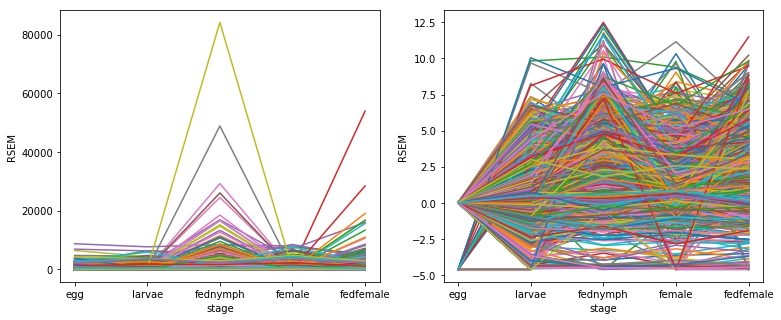

In [97]:
print("writing most variable contigs to table")
with open("top1000_norm.tsv","w") as out:
    out.write("contig\t{}\n".format("\t".join(indices)))
    for seq in list(topthousand.index):
        #print(seq, topthousand[seq]) #and this is how you extract the respective values
        data = [str(x).replace(".",",") for x in array[seq][-5:]] #index important to extract only the stage RSEMs
        data = "\t".join(data)
        out.write("{}\t{}\n".format(seq, data))

print("plotting data")
labels = indices
plt.style.context('Solarize_Light2')
fig, (ax1,ax2) = plt.subplots(1,2, sharey=False, figsize=(12.6,5))
ax1.plot(x, y)
ax1.set(xlabel="stage", ylabel="RSEM")
ax1.set_xticks(x)
ax1.set_xticklabels(stages)
#for tick in ax1.get_xticklabels():
#    tick.set_rotation(55)

ax2.plot(x, y_n)
ax2.set(xlabel="stage", ylabel="RSEM")
ax2.set_xticks(x)
ax2.set_xticklabels(stages)
#for tick in ax2.get_xticklabels():
#    tick.set_rotation(55)

fig.savefig("variances.png")
plt.show()

# This is the real clustering analysis, using Morpheus output

In [2]:
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.spatial.distance import cdist,pdist
from scipy.stats import pearsonr
from math import ceil, isnan

Xsub = X.loc[:,"egg":"fedfemale"] #used to be Xstd.loc[:,"egg_n":"fedfemale_n"]
stages = ['egg', 'larvae', 'fednymph', 'female', 'fedfemale']
standardized = ['egg', 'larvae', 'fednymph', 'female', 'fedfemale'] #bc normalized data are read
treatments = allcolumns[:allcolumns.index("egg")]
#optionally, add more treatments:
#treatments = ['k_means_40', 'k_means_50', 'k_means_60']
print("Found data for clustering methods:")
print(", ".join(treatments))
stagesn = [1, 2, 3, 4, 5]


Found data for clustering methods:
dendro_10, dendro_11, dendro_12, dendro_13, dendro_15, dendro_17, dendro_19, dendro_23, dendro_25, dendro_27, dendro_31, dendro_36, dendro_4, dendro_42, dendro_50, dendro_6, dendro_7, dendro_9, k_means_2, k_means_3, k_means_5, k_means_7, k_means_9, k_means_11, k_means_13, k_means_10, k_means_15, k_means_17, k_means_20, k_means_23, k_means_26, k_means_30, k_means_35, k_means_40, k_means_50


In [3]:
#these all relate to new clustering metrics calculating
reportfile = open("clustering_report_norm_1-Pearson.txt", "w")
errorfile = open("errors_clustering_metrics.txt", "w")
centroids = {}
badclusters = set()
plotx = []
ploty = []
plot_dict = {} #this would allow sorting the treatments, 
                #but would also lose the value for dendrogram_28 - same key as kmean_28

allcent = list(Xsub.mean())
print("all points centroid", allcent)
    

for kmean in treatments[:]:   
    cluststats = {}
    maxmodules = int(kmean.split("_")[-1])
    centroids[kmean] = ([], "variability")
    print("Analyzing data for: " + kmean)
    reportfile.write("{} with max modules {}\n".format(kmean, maxmodules))
    cluster_labels_morpheus = np.array(X[kmean], dtype=np.int32)
    for cluster in range(1,maxmodules + 1):
        #determine which contigs belong to this cluster
        contigs = Xsub[X[kmean] == cluster]
        #variance = np.var(Xsub.loc[:,:], axis=0) #limits calculation to columns defined after the comma
        #print(cluster, len(contigs)) #make sure all the clusters are analyzed
        #print("number of contigs per module:", contigs.shape[0]) #same thing
        cluststats["{}_{}".format(maxmodules, cluster)] = {"mean": contigs.mean(), 
                                                           "std": contigs.std(), 
                                                           "count": contigs.count()["egg"]}
        #print(contigs.describe()) #only for control, or to find out what other stats are readily available
        # calculate within-cluster variance
        centroids[kmean][0].append(list(contigs.mean()))
    cent = np.array(centroids[kmean][0]) #list of clusters centroids
    
    #calculate minimum distance of each contig to any centroid:
    
    D_k = [cdist(Xsub, c, 'euclidean') for c in [cent]]
    #cIdx = [np.argmin(D,axis=1) for D in D_k]
    dist = [np.min(D,axis=1) for D in D_k]
    reportfile.write("distvalues: {}, ".format(len(dist[0])))
    dist = [d[~np.isnan(d)] for d in dist] # ~ >> logical not
    reportfile.write("distvalues without NaN: {}\n".format(len(dist[0])))
    #some distance stats:
    tot_withinss = [sum(d**2) for d in dist]    # Total within-cluster sum of squares
    reportfile.write("total within-cluster distance sqsum:\t{}\n".format(tot_withinss[0]))  
    totss = sum(pdist(Xsub.dropna(how='any'))**2)/Xsub.shape[0]  # The total sum of squares
    reportfile.write("total distance sqsum:\t{}\n".format(totss))
    betweenss = totss - tot_withinss           # The between-cluster sum of squares
    reportfile.write("total explained distance sqsum:\t{}({:.2f}%)\n\n"\
                     .format(betweenss[0], 100 * betweenss[0]/totss))
    
    
    #1-Pearson correlation CALCULATED WITHIN-GROUP/GLOBALLY
    tot_withinps = 0
    tot_ps = 0 # 22741.720695223998 22798.02672928206 #calculated previously from 1-Pearson distance from average centroid
    Xsub_noNaN = Xsub.dropna(how='any')
    c = 0
    for x in range(1, Xsub_noNaN.shape[0] + 1): #go through all valid clusters
        point = np.array(Xsub_noNaN[x-1:x])[0] #no more runtime error?
        #if x > Xsub_noNaN.shape[0] - 1: #this was to troubleshoot
        #    print(x, point)        
        value = np.min([1 - pearsonr(point, c)[0] for c in cent])
        avgvalue = 1 - pearsonr(point,allcent)[0]
        if not isnan(value):
            tot_withinps += value
            c += 1
            tot_ps += avgvalue
        elif Xsub_noNaN[x-1:x].index[0] not in badclusters:
            errorfile.write("bad cluster {}\n".format(Xsub_noNaN[x-1:x].index[0]))
            badclusters.add(Xsub_noNaN[x-1:x].index[0])

    print("sum of within-cluster variability: {} ({} total)".format(tot_withinps, tot_ps))
    #print(str(c), "valid floats added")
    plotx.append(maxmodules)
    ploty.append((tot_ps - tot_withinps)/tot_ps*100)
    reportfile.write("total within-cluster 1-pearson:\t{}\t{:.2f}% of total explained\n\n"\
                     .format(tot_withinps, (tot_ps - tot_withinps)/tot_ps*100))
    
    #make an array of plots
    """    
    fig, axs = plt.subplots(nrows=ceil(maxmodules/5), ncols=5, figsize=(12.6, 0.4*maxmodules), sharex=True,
                            subplot_kw={'xticks': stagesn}) #'yticks': [] to leave empty ax
    fig.subplots_adjust(left=0.05, right=0.97, hspace=0.3, wspace=0.3)
    fig.suptitle('RSEM across stages for individual clusters ({})'.format(kmean))

    for i, data in enumerate(cluststats.keys()):
        y = cluststats[data]["mean"]
        err = cluststats[data]["std"]
        axs[i//5,i%5].plot(stagesn, cluststats[data]["mean"], color="darkred", linewidth=3)
        axs[i//5,i%5].axhline(y=0, color='k')
        #axs[i//5,i%5].xticks(np.arange(5), stages)
        suptitle = "{} ({} genes)".format(data, cluststats[data]["count"])
        axs[i//5,i%5].set_title(suptitle)
        axs[i//5,i%5].fill_between(stagesn, y-err, y+err, facecolor="red", alpha=0.2)
        #some other parameters for the shading: edgecolor=, antialiased=True 
        #axs[i//5,i%5].errorbar(stagesn, cluststats[data]["mean"], yerr=cluststats[data]["std"], \
        #                       linewidth=0, elinewidth=1)
        axs[i//5,i%5].set_xticklabels(stages)
        for tick in axs[i//5,i%5].get_xticklabels():
            tick.set_rotation(55)
 
    plt.savefig(kmean + "_shade_plots.pdf")                                      
    plt.show()"""
    print("Success!")

reportfile.write("table for elbow plot:\n")
for i in range(len(plotx)):
    reportfile.write("{}\t{}\n".format(plotx[i], ploty[i]))

#comment
print("Closing report file, now to plot graph...")
reportfile.close()
errorfile.close()


all points centroid [-0.25948568088837115, -0.27196376388076954, 0.5635125657510232, -0.3784404831482545, 0.3464075589323977]
Analyzing data for: dendro_10
sum of within-cluster variability: 827.5992008175687 (8460.469155796476 total)
Success!
Analyzing data for: dendro_11
sum of within-cluster variability: 769.1437514312732 (8460.469155796476 total)
Success!
Analyzing data for: dendro_12
sum of within-cluster variability: 755.9640159071623 (8460.469155796476 total)
Success!
Analyzing data for: dendro_13
sum of within-cluster variability: 705.8429068613419 (8460.469155796476 total)
Success!
Analyzing data for: dendro_15
sum of within-cluster variability: 673.5701126455988 (8460.469155796476 total)
Success!
Analyzing data for: dendro_17
sum of within-cluster variability: 650.7960314948684 (8460.469155796476 total)
Success!
Analyzing data for: dendro_19
sum of within-cluster variability: 556.5364379187506 (8460.469155796476 total)
Success!
Analyzing data for: dendro_23
sum of within-clus

In [4]:
import pickle

#do not write pickle unless you have run the clustering analysis!
#with open("centroids.pkl", "wb") as pkl:
#    pickle.dump(centroids, pkl, protocol=pickle.HIGHEST_PROTOCOL)    
#with open("centroids.pkl", "rb") as pkl:
#    centroids = pickle.load(pkl)

print(plotx)
print(ploty)

[10, 11, 12, 13, 15, 17, 19, 23, 25, 27, 31, 36, 4, 42, 50, 6, 7, 9, 2, 3, 5, 7, 9, 11, 13, 10, 15, 17, 20, 23, 26, 30, 35, 40, 50]
[90.21804600220591, 90.90897044516363, 91.06475064223557, 91.65716588686158, 92.03861984197272, 92.30780209098697, 93.42191989982666, 94.35051968572388, 94.596510992198, 94.77247618648552, 95.31499558264802, 95.75170372533653, 80.16287928869644, 96.07840879688922, 96.3864158164511, 85.4210118256561, 87.13112319811093, 89.41137632545329, 55.79724032071799, 75.80809585876925, 84.4901718288943, 88.90412816686609, 90.74494633094956, 92.20036234105827, 93.06297577579602, 91.05715909556366, 93.3863082244526, 93.95834197475882, 94.6705010663114, 95.03925122188062, 95.44885873841555, 95.7534760149032, 96.16248523331097, 96.44257042984071, 96.98679560106032]


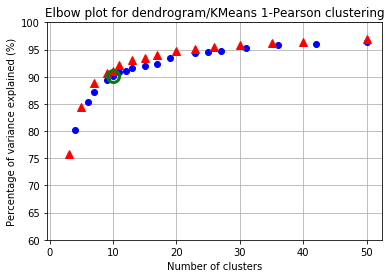

Analysis done!


In [7]:
# elbow curve
fig = plt.figure()
ax = fig.add_subplot(111)
#there are 19 dendrogram clustering possibilities, remaining are k-means
d = len([x for x in treatments if x.startswith("dendro")])

# I screwed up, so these are manually entered values
#plotx = [10, 12, 14, 16, 18, 20, 22, 25, 29, 32, 38, 4, 43, 48, 57, 6, 8, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 25, 29, 32, 37, 43, 48, 57]
#ploty = [90.32897283272004, 90.9900535062928, 91.91364847055861, 92.52177157367437, 93.03122950270357, 93.38552961522886, 93.57586264387777, 94.04950913719917, 94.25738576669261, 95.08222699276759, 95.42965884261268, 72.55791946489119, 95.68236446785953, 95.93897973448325, 96.53866774368294, 83.84507115050741, 87.21953596133139, 54.967603758237225, 80.28370359146388, 86.98578581300131, 89.78037388649291, 91.61556287561878, 92.54957148108053, 93.07060753426836, 93.68486114711071, 94.04262151149501, 94.60345753922846, 94.88988844647889, 95.27626778215725, 95.6905744918455, 95.88667720138292, 96.2921944719472, 96.63883063552194, 96.86962880633129, 97.17092908273814]
#d = 19

#dendro values
ax.plot(plotx[:d], ploty[:d], 'bo-', linewidth=0, markersize=6)
#k-means values
ax.plot(plotx[d:], ploty[d:], 'r^--', linewidth=0, markersize=8)

#mark the best cluster number
best = 0 #or 21
#print("best cluster", treatments[best])
ax.plot(plotx[best], ploty[best], marker='o', markersize=12, 
    markeredgewidth=3, markeredgecolor='g', markerfacecolor='None')
ax.set_ylim((60,100)) # 80-100%
plt.grid(True)
plt.xlabel('Number of clusters')
plt.ylabel('Percentage of variance explained (%)')
plt.title('Elbow plot for dendrogram/KMeans 1-Pearson clustering')

plt.savefig("clustering_elbow.pdf") 
plt.show()
print("Analysis done!")

In [3]:
import pickle

#load the centroids dict pickle
with open("centroids.pkl", "rb") as pkl:
    centroids = pickle.load(pkl)
    print("Pickle of centroids loaded")

Pickle of centroids loaded


Plotting data for: dendro_10
            egg  larvae  fednymph  female  fedfemale
id                                                  
c78653_g2 -0.72    0.42     -0.22    0.62      -0.11
c75863_g1 -2.80    1.37     -1.12    2.53       0.01
c73727_g1 -3.11    1.37     -0.89    2.52       0.11
c73292_g1 -1.47    0.49      0.02    0.89       0.08
c70120_g1 -3.58    0.98      0.41    2.14       0.04


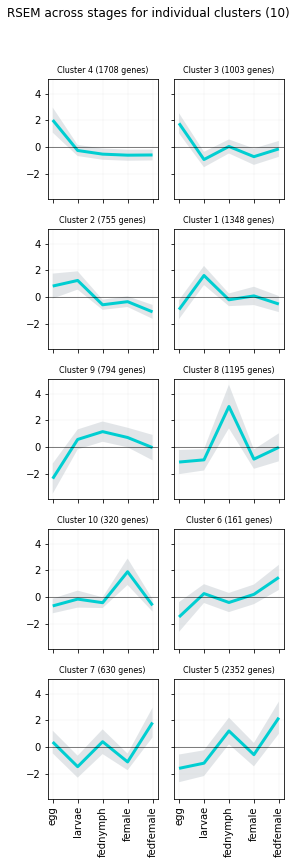

In [4]:
rearrange = {4: 0, 3: 1, 2: 2, 1: 3, 9: 4, 8: 5, 10: 6, 6: 7, 7: 8, 5:9}
#rearrange = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9}
#print(os.listdir("."))
if not os.path.isdir("submatice"):
    os.mkdir("submatice")
#ribbon plot for the best
for kmean in ["dendro_10"]:   #, "k_means_10"
    if not os.path.isdir(kmean):
        os.mkdir(kmean)
    cluststats = {}
    maxmodules = int(kmean.split("_")[-1])
    centroids[kmean] = ([], "variability")
    print("Plotting data for: " + kmean)
    cluster_labels_morpheus = np.array(X[kmean], dtype=np.int32)
    for cluster in range(1,maxmodules + 1):
        #determine which contigs belong to this cluster
        contigs = Xsub[X[kmean] == cluster]
        contigs.to_csv("submatice/{}_cluster{}.tsv".format(kmean,cluster), sep="\t")
        #print(contigs.head())
        if cluster == 1:
            #make sure that the order of characters is the same in the input and the graph
            print(contigs.head())
        #variance = np.var(Xsub.loc[:,:], axis=0) #limits calculation to columns defined after the comma
        #print(cluster, len(contigs)) #make sure all the clusters are analyzed
        cluststats["{}".format(cluster)] = {"mean": contigs.mean(), 
                                            "std": contigs.std(), 
                                            "count": contigs.count()["egg"]}

    numcols = 2
    numrows = ceil(maxmodules/numcols)
    subplotids = [i for i in range(numrows * numcols)]
    fig, axs = plt.subplots(nrows=numrows, ncols=numcols, figsize=(2*numcols, 2.5*numrows), 
                            sharex=True, sharey=True,
                            subplot_kw={'xticks': stagesn}) #'yticks': [] to leave empty ax
    fig.subplots_adjust(left=0.15, right=0.97, 
                        top=0.9, bottom=0.1, 
                        hspace=0.25, wspace=0.15)
    fig.suptitle('RSEM across stages for individual clusters ({})'.format(maxmodules))
    
    if numcols >1:
        for e, data in enumerate(cluststats.keys()):
            i = rearrange[e+1]
            y = cluststats[data]["mean"]
            err = cluststats[data]["std"]
            axs[i//numcols,i%numcols].grid(b=True, color='silver', linestyle='-', linewidth=0.1)
            axs[i//numcols,i%numcols].plot(stagesn, cluststats[data]["mean"], 
                               color="darkturquoise", 
                               linewidth=3, 
                               solid_capstyle="butt")
            axs[i//numcols,i%numcols].axhline(y=0, color='k', linewidth=0.5)
            #axs[i//numcols,i%numcols].xticks(np.arange(5), stages)
            suptitle = "Cluster {} ({} genes)".format(data, cluststats[data]["count"])
            #add title
            axs[i//numcols,i%numcols].set_title(suptitle, fontsize=8)

            #put on some shade
            axs[i//numcols,i%numcols].fill_between(stagesn, y-err, y+err, 
                                       facecolor="slategrey", 
                                       alpha=0.2)
            #some other parameters for the shading: edgecolor=, antialiased=True 
            #axs[i//5,i%5].errorbar(stagesn, cluststats[data]["mean"], yerr=cluststats[data]["std"], \
            #                       linewidth=0, elinewidth=1)
            axs[i//numcols,i%numcols].set_xticklabels(stages)
            for tick in axs[i//numcols,i%numcols].get_xticklabels():
                tick.set_rotation(90)
                tick.set_ha("center")
            subplotids.remove(i)

        for i in subplotids:
            fig.delaxes(axs[i//numcols,i%numcols])
    else:
        for e, data in enumerate(cluststats.keys()):
            i = rearrange[e+1]
            y = cluststats[data]["mean"]
            err = cluststats[data]["std"]
            axs[i].grid(b=True, color='silver', linestyle='-', linewidth=0.1)
            axs[i].plot(stagesn, cluststats[data]["mean"], 
                        
                        color="darkturquoise", 
                        linewidth=3, 
                        solid_capstyle="butt")
            axs[i].axhline(y=0, color='k', linewidth=0.5)
            suptitle = "Cluster {} ({} genes)".format(i+1, cluststats[data]["count"])
            #add title
            axs[i].set_title(suptitle, fontsize=8)

            #put on some shade
            axs[i].fill_between(stagesn, y-err, y+err, 
                                       facecolor="slategrey", 
                                       alpha=0.2)
            #some other parameters for the shading: edgecolor=, antialiased=True 
            #axs[i//5,i%5].errorbar(stagesn, cluststats[data]["mean"], yerr=cluststats[data]["std"], \
            #                       linewidth=0, elinewidth=1)
            axs[i].set_xticklabels(stages)
            for tick in axs[i].get_xticklabels():
                tick.set_rotation(90)
                tick.set_ha("center")
        
    plt.savefig(f"{kmean}/{kmean}_shade_plots.pdf")                                      
    plt.show()




Plotting data for: dendro_10
            egg  larvae  fednymph  female  fedfemale
id                                                  
c79997_g3  0.53    1.15     -0.23    0.41      -1.86
c83707_g1  0.45    0.98     -0.01    0.59      -2.00
c78984_g1  0.19    1.12      0.10   -0.05      -1.35
c80423_g2  0.41    1.19      0.19   -0.29      -1.50
c80411_g2  2.08    1.05     -0.02   -0.12      -2.99


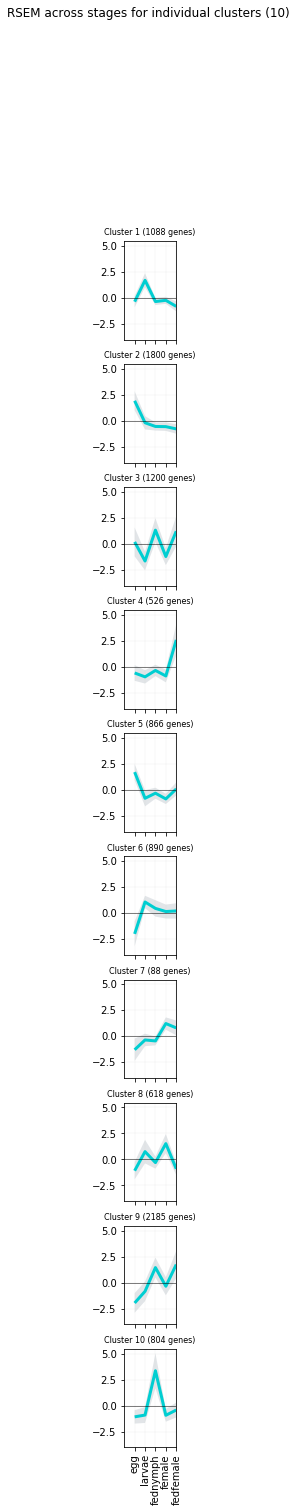

In [50]:
#ribbon plot for the best
#same as above but using tuples for subplots, takes much longer due to sharey=axs1
"""
for kmean in ["dendro_10"]:   
    cluststats = {}
    maxmodules = int(kmean.split("_")[-1])
    centroids[kmean] = ([], "variability")
    print("Plotting data for: " + kmean)
    cluster_labels_morpheus = np.array(X[kmean], dtype=np.int32)
    for cluster in range(1,maxmodules + 1):
        #determine which contigs belong to this cluster
        contigs = Xsub[X[kmean] == cluster]
        contigs.to_csv("submatice/{}_cluster{}.tsv".format(kmean,cluster), sep="\t")
        #print(contigs.head())
        if cluster == 1:
            #make sure that the order of characters is the same in the input and the graph
            print(contigs.head())
        #variance = np.var(Xsub.loc[:,:], axis=0) #limits calculation to columns defined after the comma
        #print(cluster, len(contigs)) #make sure all the clusters are analyzed
        cluststats["{}".format(cluster)] = {"mean": contigs.mean(), 
                                            "std": contigs.std(), 
                                            "count": contigs.count()["egg"]}

    numcols = 1
    numrows = ceil(maxmodules/numcols)
    subplotids = [i for i in range(numrows * numcols)]
    fig, axs = plt.subplots(nrows=numrows, ncols=numcols, figsize=(2*numcols, 2.5*numrows), 
                            sharex=True, sharey=True,
                            subplot_kw={'xticks': stagesn}) #'yticks': [] to leave empty ax
    fig.subplots_adjust(left=0.05, right=0.97, 
                        top=0.85, bottom=0.18, 
                        hspace=0.25, wspace=0.15)
    fig.suptitle('RSEM across stages for individual clusters ({})'.format(maxmodules))

    for i, data in enumerate(cluststats.keys()):
        y = cluststats[data]["mean"]
        err = cluststats[data]["std"]
        axs1 = plt.subplot(numrows, numcols, i+1, sharey=axs1)
        axs1.set_xticks(stagesn)
        axs1.grid(b=True, color='silver', linestyle='-', linewidth=0.1)
        axs1.plot(stagesn, cluststats[data]["mean"], 
                           color="darkturquoise", 
                           linewidth=3, 
                           solid_capstyle="butt")
        axs1.axhline(y=0, color='k', linewidth=0.5)
        suptitle = "Cluster {} ({} genes)".format(data, cluststats[data]["count"])
        #add title
        axs1.set_title(suptitle, fontsize=8)
        
        #put on some shade
        axs1.fill_between(stagesn, y-err, y+err, 
                                   facecolor="slategrey", 
                                   alpha=0.2)
        #some other parameters for the shading: edgecolor=, antialiased=True 
        #axs[i//5,i%5].errorbar(stagesn, cluststats[data]["mean"], yerr=cluststats[data]["std"], \
        #                       linewidth=0, elinewidth=1)
        if i in [9]:
            axs1.set_xticklabels(stages)
        else:
            axs1.set_xticklabels(["", "", "", "", ""])
        for tick in axs1.get_xticklabels():
            tick.set_rotation(90)
            tick.set_ha("center")
        subplotids.remove(i)

    for i in subplotids:
        fig.delaxes(axs[i//numcols,i%numcols])
    plt.savefig(kmean + "_shade_plots.pdf")                                      
    plt.show()

"""

In [12]:
files = [x for x in os.listdir()]
files.sort()
print(files)


['.DS_Store', 'centroids.pkl', 'clustering_elbow.pdf', 'clustering_report_norm_1-Pearson.txt', 'cpm2.RLEbyHK.id.tabs', 'dendro_10', 'dendro_10.gct', 'dendro_11.gct', 'dendro_12.gct', 'dendro_13.gct', 'dendro_15.gct', 'dendro_17.gct', 'dendro_19.gct', 'dendro_23.gct', 'dendro_25.gct', 'dendro_27.gct', 'dendro_31.gct', 'dendro_36.gct', 'dendro_4.gct', 'dendro_42.gct', 'dendro_50.gct', 'dendro_6.gct', 'dendro_7.gct', 'dendro_9.gct', 'diffExpr.P0.001_C2.matrix.log2.centered.dat', 'diffExpr.P0.001_C2.matrix.log2.centered.dat.json', 'diffExpr.P0.001_C2.matrix.log2.centered.kmeans.dat.json', 'errors_clustering_metrics.txt', 'kliste_matice_klastry.pkl', 'kmeans.gct', 'submatice']


In [13]:
#gene list for the best
outdir = "coexpressed_lists"
os.chdir(wd)
#if needed, you can load the go_terms file
"""
goterms = {}
with open("../GO-goatools.tsv") as f:
    for line in f:
        data = line.strip().split()
        goterms[data[0]] = data[1]
"""
#read non-differentially expressed filtered contigs
#filtered_contig_file = "merged.cpm2.TMMbyHK.id.tabs" 
#filtered_contig_file = "merged.cpm2.TMMbyHK.BCV0.4138.id.tabs" 
filtered_contig_file = "cpm2.RLEbyHK.id.tabs"
filtdf = pd.read_csv(filtered_contig_file, delimiter="\t")
filtdf = filtdf.set_index("raw.id")
filtdf.dropna(how="all", inplace=True)
nonDE  = filtdf[filtdf.isnull().any(axis=1)]
print(nonDE.head())
nonDElist = list(nonDE.index.values)
#DElist = list(filtdf.dropna(how="any").index.values)

for kmean in ["dendro_10", "k_means_10"]:
    sorted = 0
    if os.path.isdir(kmean):
        os.chdir(kmean)
    else:
        print("Making new datadir", kmean)
        os.mkdir(kmean)
        os.chdir(kmean)
    if not os.path.isdir(outdir):
        os.mkdir(outdir)
        os.mkdir("enrichment")
    popfile = open("{}/population.txt".format(outdir), "w")
    cluststats = {}
    maxmodules = int(kmean.split("_")[-1])
    centroids[kmean] = ([], "variability")
    print("Plotting data for: " + kmean)
    cluster_labels_morpheus = np.array(X[kmean], dtype=np.int32)
    for cluster in range(1,maxmodules + 1):
        #determine which contigs belong to this cluster
        contigs = Xsub[X[kmean] == cluster]
        contiglist = [c for c in contigs.index]
        with open("{}/cl{}.txt".format(outdir, cluster), "w") as out:
            for item in contiglist:
                out.write("{}\n".format(item))
                popfile.write("{}\n".format(item))
        print(len(contiglist), "contigs listed")
        sorted += len(contiglist)
    print("sum:", sorted)
    with open("{}/cl{}.txt".format(outdir, maxmodules + 1), "w") as out:
        print(len(nonDElist), "contigs listed as non-DE")
        out.write("\n".join(nonDElist))
        popfile.write("\n".join(nonDElist))
        #print(len(DElist), "contigs listed as DE")
    popfile.close()
    os.chdir("..")


          cpm2.filter.id cpm2.DE.id
raw.id                             
c10472_g1      c10472_g1        NaN
c10507_g1      c10507_g1        NaN
c10578_g1      c10578_g1        NaN
c10581_g1      c10581_g1        NaN
c10609_g1      c10609_g1        NaN
Plotting data for: dendro_10
1348 contigs listed
755 contigs listed
1003 contigs listed
1708 contigs listed
2352 contigs listed
161 contigs listed
630 contigs listed
1195 contigs listed
794 contigs listed
320 contigs listed
sum: 10266
20832 contigs listed as non-DE
Making new datadir k_means_10
Plotting data for: k_means_10
2012 contigs listed
1281 contigs listed
677 contigs listed
624 contigs listed
829 contigs listed
601 contigs listed
1554 contigs listed
1046 contigs listed
962 contigs listed
680 contigs listed
sum: 10266
20832 contigs listed as non-DE


In [14]:
#NOW READY FOR GOATOOLS!

just a cute random polar plot:

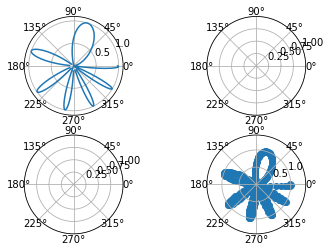

In [126]:
x = np.linspace(0, 2*np.pi, 400)
y = np.sin(x**2)
fig, axes = plt.subplots(2, 2, subplot_kw=dict(polar=True))
axes[0, 0].plot(x, y)
axes[1, 1].scatter(x, y)
plt.show()

In [71]:
#calculation of optimal cluster number by the elbow method:
#https://stackoverflow.com/questions/6645895/calculating-the-percentage-of-variance-measure-for-k-means?lq=1#
from scipy.cluster.vq import kmeans,vq
from scipy.spatial.distance import cdist,pdist
import matplotlib.pyplot as plt

# load the iris dataset
#fName = 'C:\\Python27\\Lib\\site-packages\\scipy\\spatial\\tests\\data\\iris.txt'
#fp = open(fName)
#X = np.loadtxt(fp)
#fp.close()
XsubNORM = X.loc[:,"egg_n":"fedfemale_n"]
XsubKM = XsubNORM.dropna(how='any')

##### cluster data into K=1..40 clusters #####
maxK = 40
K = range(1,maxK + 1, 5)

# scipy.cluster.vq.kmeans
KM = [kmeans(XsubKM,k) for k in K]
#print(KM) #reveals that KM is a tuple of centroids for each subgroup and total variance 
centroids = [cent for (cent,var) in KM]   # cluster centroids
#avgWithinSS = [var for (cent,var) in KM] # mean within-cluster sum of squares

# alternative: scipy.cluster.vq.vq
#Z = [vq(X,cent) for cent in centroids]
#avgWithinSS = [sum(dist)/X.shape[0] for (cIdx,dist) in Z]

# alternative: scipy.spatial.distance.cdist
D_k = [cdist(XsubKM, cent, 'euclidean') for cent in centroids]
cIdx = [np.argmin(D,axis=1) for D in D_k]
dist = [np.min(D,axis=1) for D in D_k]
#avgWithinSS = [sum(d)/XsubKM.shape[0] for d in dist]

tot_withinss = [sum(d**2) for d in dist]  # Total within-cluster sum of squares
print(tot_withinss)
totss = sum(pdist(XsubKM)**2)/XsubKM.shape[0]       # The total sum of squares
print(totss)
betweenss = totss - tot_withinss          # The between-cluster sum of squares



[array([2.48701204, 2.81981493, 4.27519653, ..., 4.54481165, 2.1468083 ,
       3.95089516])]
[151249.9903200069, 66364.3421679599, 46510.50898299962, 37846.020346275254, 31909.313440912567, 28010.9839937852, 24724.208803846977, 22319.878076890174]
151249.99032111024


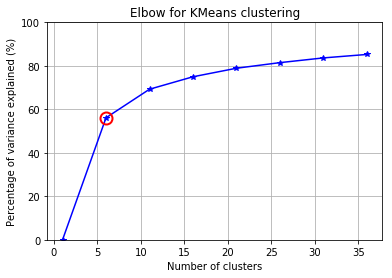

In [74]:
from matplotlib import cm
##### plots #####
kIdx = 1        # mark down K=29
clr = cm.spectral( np.linspace(0,1,10) ).tolist()
mrk = 'os^p<dvh8>+x.'

# elbow curve
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(K, betweenss/totss*100, 'b*-')
ax.plot(K[kIdx], betweenss[kIdx]/totss*100, marker='o', markersize=12, 
    markeredgewidth=2, markeredgecolor='r', markerfacecolor='None')
ax.set_ylim((0,100))
plt.grid(True)
plt.xlabel('Number of clusters')
plt.ylabel('Percentage of variance explained (%)')
plt.title('Elbow for KMeans clustering')

plt.show()

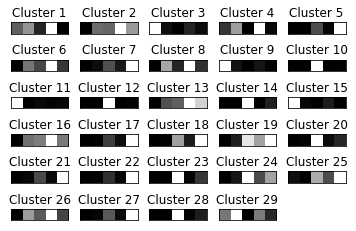

In [49]:
# show centroids for K=20 clusters
plt.figure()
for i in range(kIdx+1):
    img = centroids[kIdx][i].reshape(1,5)
    ax = plt.subplot(6,5,i+1)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.imshow(img, cmap=cm.gray)
    plt.title( 'Cluster {}'.format(i + 1))
plt.savefig("clusters_reshaped.png")
plt.show()

# the following section was for testing only

# this is performance analysis of the clustered filtered contigs

In [144]:
import numpy as np
import pandas as pd
import os

homedir = "/Users/zoliq/ownCloud/"
#homedir = "/Volumes/zoliq data/ownCloud/"
wd = homedir + "Jankoviny/Tick_transcriptome/klastrovani"
os.chdir(wd)

array = {}

with open("kliste_hierch99_kmean20-200.gct") as f:
    c = 0
    for l in f:
        if c == 2:
            c += 1
            allcolumns = l.strip().split("\t")[1:]
            allcolumns = [x.replace(".RSEM","") for x in allcolumns]
            print("identified columns:")
            print(allcolumns)
        elif c < 3:
            c += 1
            print("ignored:" + l.strip())
        else:
            data = l.strip().split("\t")
            array[data[0]] = [float(x) for x in data[1:]]
print("reading morpheus infile finished")

ignored:#1.3
ignored:26744	5	10	0
identified columns:
['dendrogram_99', 'k_means_28', 'k_means_25', 'k_means_30', 'k_means_20', 'k_means_35', 'k_means_100', 'k_means_75', 'k_means_150', 'k_means_200', 'egg', 'larvae', 'fednymph', 'female', 'fedfemale']
reading morpheus infile finished


In [145]:
df = pd.DataFrame(array, index=allcolumns, dtype=np.float64)
X = df.T
#indices = ['dendrogram_28', 'k_means_28', 'k_means_25', 'k_means_30', 'k_means_20', 'k_means_35', 'egg', 'larvae', 'fednymph', 'female', 'fedfemale']
indices = ['egg', 'larvae', 'fednymph', 'female', 'fedfemale']
Xsub = X[indices] #or give a list of subsets to keep

In [146]:
print(X.loc[:,"egg":].head(10))
#print(df.T)
#print(X)

            egg  larvae  fednymph  female  fedfemale
c10016_g1  1.00    0.35      0.00    1.60       1.38
c10039_g1  2.83    0.30      0.29    0.00       0.78
c10097_g1  0.00    0.00      0.00    3.21       0.00
c10119_g1  0.73    0.20      1.11    0.44       0.75
c10161_g1  0.09    0.02      2.86    1.70       2.80
c10203_g1  0.00    3.48      0.00    0.00       0.00
c1021_g1   0.88    0.00      0.43    0.00       0.00
c10235_g1  0.00    2.03      0.00    0.00       0.53
c10265_g1  0.00    4.32      1.08    3.26       1.86
c10295_g1  0.95    1.00      0.00    0.00       0.67


In [15]:
# the following is for calculation of variances on the filtered set of contigs, 
# essentially the same as above

In [16]:
#variance = np.var(X, axis=1) #0=x-axis, 1=y-axis
variance = np.var(X.loc[:,"egg":], axis=1) #limits calculation to columns defined after the comma

In [21]:
sortedvar = variance.sort_values(ascending=0, inplace=False)
topthousand = sortedvar.head(1000)
list(topthousand.index)[:5] #this is how you extract indices from a np.series

['c81210_g1', 'c56425_g1', 'c80070_g2', 'c69505_g1', 'c79647_g1']

silhouette tests and stuff:

In [22]:
#this section is to calculate per-module sum-of-square/avg.silhouette

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

#X = df.T
Xsub = X.loc[:,"egg":] #should be same as Xsub = X[indices]
print("available clustering data:")
treatments = sorted(allcolumns[:allcolumns.index("egg")])
print(treatments) #subset of clustering protocols used
#print(X.head(10)) #to check if everything is fine
for kmean in treatments:
    maxmodules = int(kmean.split("_")[-1])
    #n_modules.append(maxmodules)
    print(kmean, maxmodules)
    cluster_labels_morpheus = np.array(X[kmean], dtype=np.int32)
    silhouette_avg = silhouette_score(Xsub, cluster_labels_morpheus)
    print("The average silhouette score is:", silhouette_avg)

#it is weird why the silhouette scores are negative for these clustering sets
#i tried other evaluation methods but i ended up with elbow test, see next section

available clustering data:
['dendrogram_28', 'k_means_20', 'k_means_25', 'k_means_28', 'k_means_30', 'k_means_35']
dendrogram_28 28
The average silhouette score is: -0.6861755519584396
k_means_20 20
The average silhouette score is: -0.41383380866375186
k_means_25 25
The average silhouette score is: -0.4526002225155799
k_means_28 28
The average silhouette score is: -0.4841625564482477
k_means_30 30
The average silhouette score is: -0.5028867105021053
k_means_35 35
The average silhouette score is: -0.5027330649954106


In [24]:
# this is to do the same with in-built K-means

In [35]:
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import silhouette_samples, silhouette_score
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling

Xsub = X.loc[:,"egg":]
n_modules = []
for maxmodules in range(2,15):
    kmeans = KMeans(n_clusters=maxmodules, random_state=10)
    cluster_labels = kmeans.fit_predict(Xsub)
    #spectral clustering takes a lot of time and produces an error: Graph is not fully connected!
    #spectral = SpectralClustering(n_clusters=maxmodules, random_state=10)
    #cluster_labels = spectral.fit_predict(Xsub)
    print("Calculating fit, n_clusters: {}".format(maxmodules))
    silhouette_avg = silhouette_score(Xsub, cluster_labels)
    
    #print("The average silhouette score for {} modules is {}:".format(maxmodules, silhouette_avg))
    print(kmeans.cluster_centers_)


Calculating fit, n_clusters: 2
[[1.87538991e+01 2.18952026e+01 2.94602982e+01 5.76648816e+01
  5.56271482e+01]
 [2.24100000e+01 2.53600000e+01 2.56950000e+01 6.65367150e+04
  4.87030000e+02]]
Calculating fit, n_clusters: 3
[[1.70916781e+01 2.00091078e+01 2.70518768e+01 3.72705969e+01
  3.53495552e+01]
 [2.24100000e+01 2.53600000e+01 2.56950000e+01 6.65367150e+04
  4.87030000e+02]
 [8.06646667e+02 9.15904167e+02 1.17105208e+03 9.72455583e+03
  9.66720625e+03]]
Calculating fit, n_clusters: 4
[[1.70944804e+01 2.00120213e+01 2.70558924e+01 3.46321725e+01
  3.71317646e+01]
 [2.24100000e+01 2.53600000e+01 2.56950000e+01 6.65367150e+04
  4.87030000e+02]
 [5.48800000e+01 5.05650000e+01 2.55330000e+02 7.22695000e+02
  4.12179900e+04]
 [8.02169583e+02 9.11977083e+02 1.15012583e+03 1.09178304e+04
  5.39070083e+03]]
Calculating fit, n_clusters: 5
[[1.29627795e+01 1.41911047e+01 1.91888626e+01 2.77474287e+01
  2.61491026e+01]
 [2.24100000e+01 2.53600000e+01 2.56950000e+01 6.65367150e+04
  4.8703000

In [7]:
maxmodules = 15
#this is for a single cluster analysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
Xsub = X.loc[:,"egg":]
kmeans = KMeans(n_clusters=maxmodules, random_state=10)
cluster_labels = kmeans.fit_predict(Xsub)
#i would get the same using:
cluster_labels_morpheus = np.array(X.k_means_15, dtype=np.int32)
#silhouette_avg = silhouette_score(Xsub, cluster_labels_morpheus)
#print("The average silh score is:", silhouette_avg)

In [8]:
#this is memory-demanding but doable for 11000 contigs
silhouette_avg = silhouette_score(Xsub, cluster_labels_morpheus)
print("The average silh score is:", silhouette_avg)

The average silh score is: -0.4981674512978522


In [9]:
#compute silhouette scores for each sample
sample_silhouette_values = silhouette_samples(Xsub, cluster_labels_morpheus)

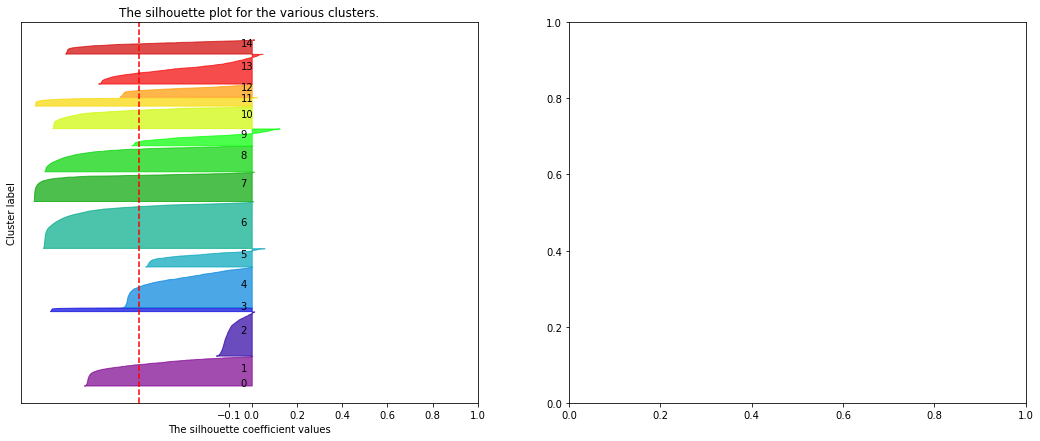

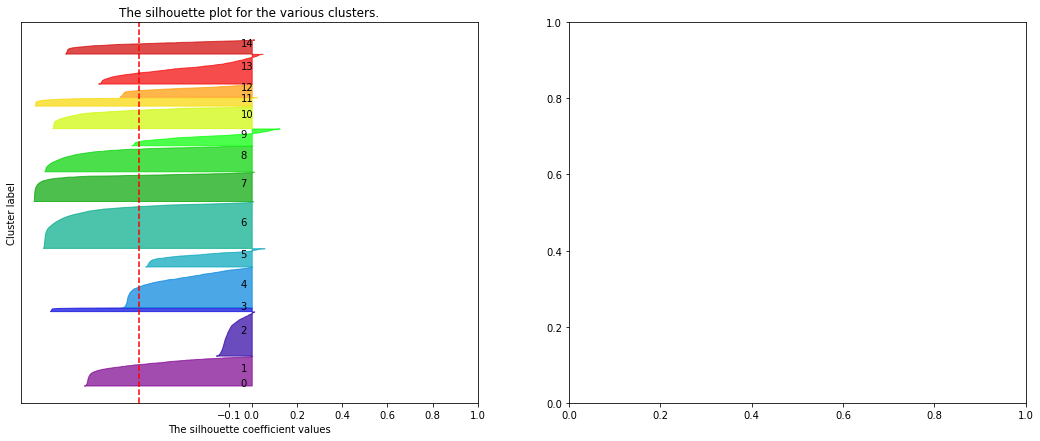

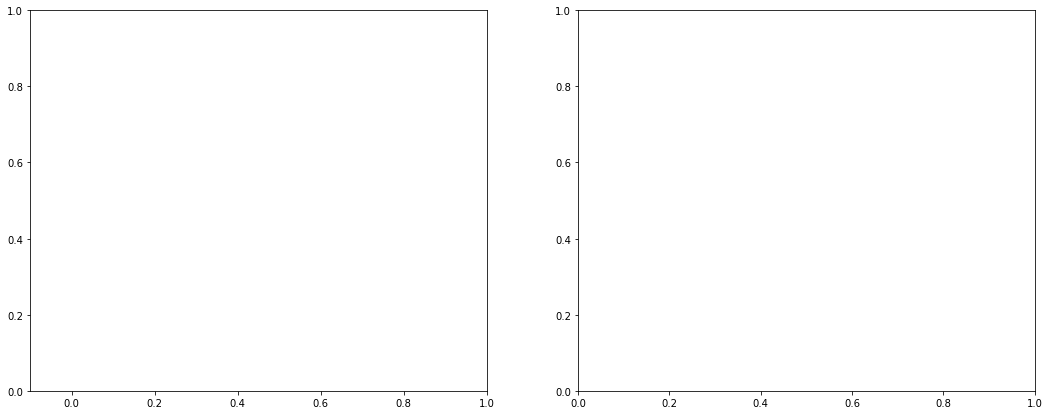

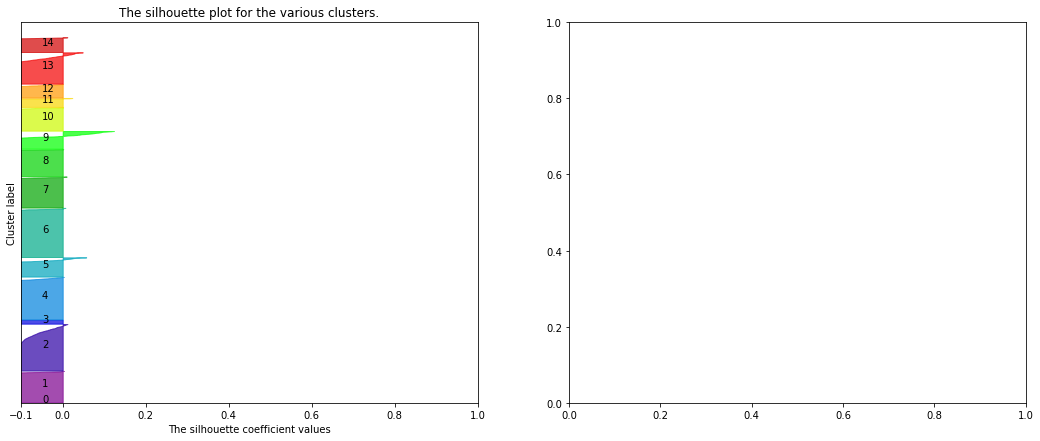

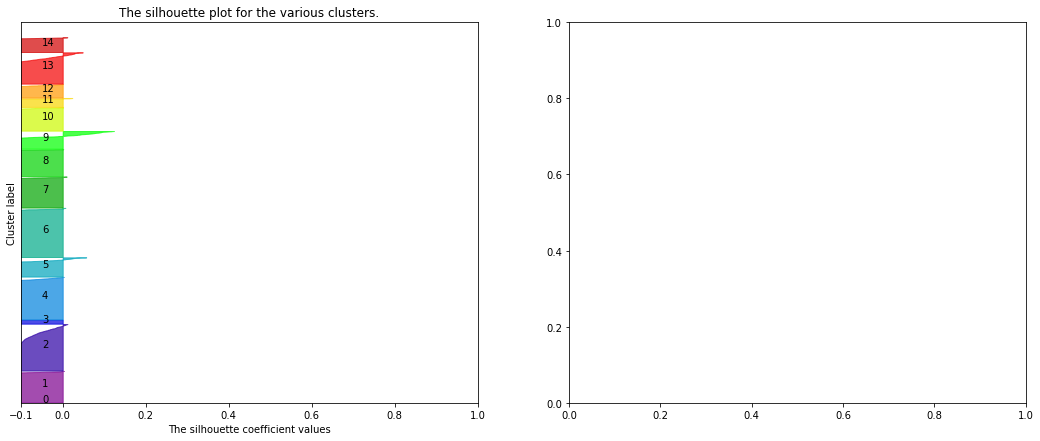

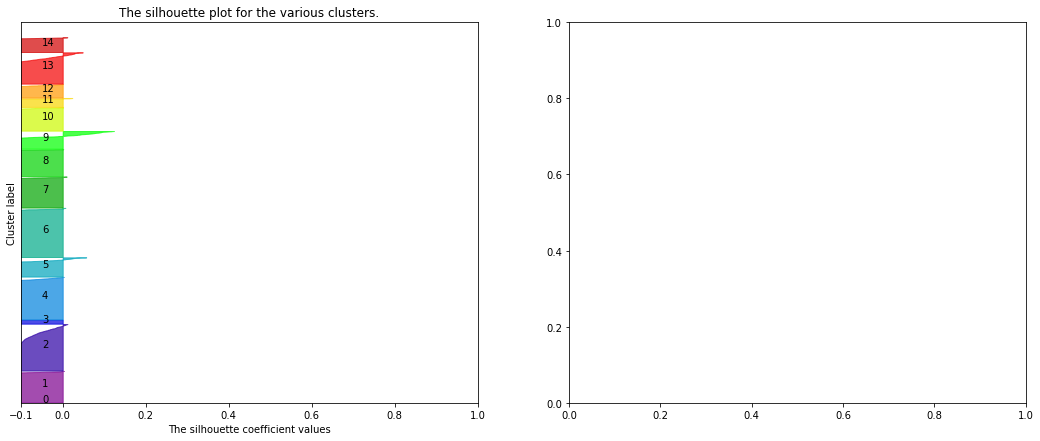

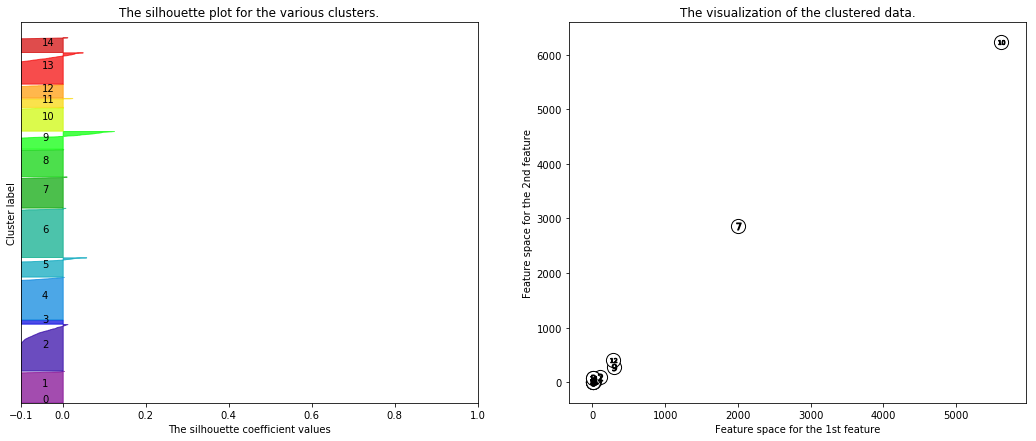

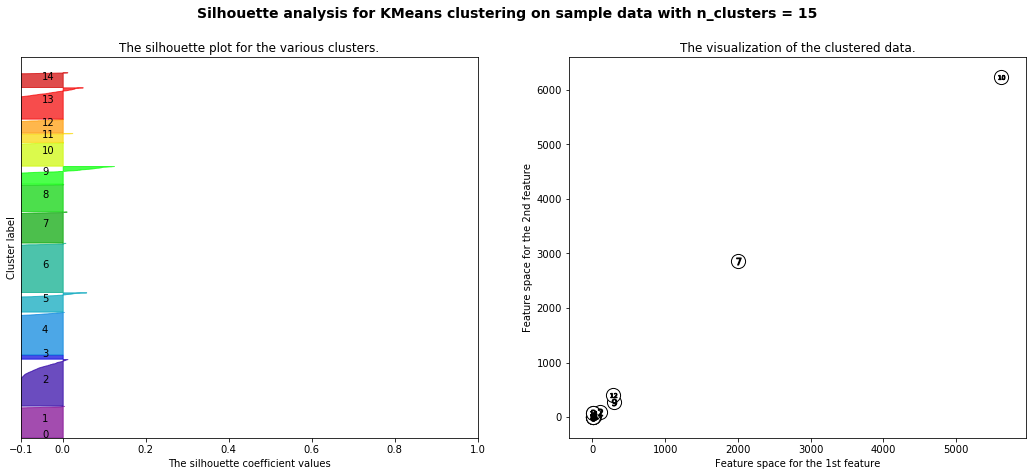

In [19]:
#this is to plot silhouette distributions for each module for n_clusters = 15
maxmodules = 15
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Create a subplot with 1 row and 2 columns    
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(18, 7)
ax1.set_xlim([-0.1, 1])
ax1.set_ylim([0, len(X) + (maxmodules + 1) * 10])

y_lower = 10
for i in range(maxmodules):
    # Aggregate the silhouette scores for samples belonging to
    # cluster i, and sort them
    ith_cluster_silhouette_values = \
        sample_silhouette_values[cluster_labels_morpheus == i]

    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / maxmodules)
    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title("The silhouette plot for the various clusters.")
ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster label")

# The vertical line for average silhouette score of all the values
ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

ax1.set_yticks([])  # Clear the yaxis labels / ticks
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# 2nd Plot showing the actual clusters formed
colors = cm.nipy_spectral(cluster_labels.astype(float) / maxmodules)
#ax2.scatter(Xsub[:, 0], Xsub[:, 1], marker='.', s=30, lw=0, alpha=0.7,
#            c=colors, edgecolor='k')

# Labeling the clusters
centers = kmeans.cluster_centers_
# Draw white circles at cluster centers
ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
            c="white", alpha=1, s=200, edgecolor='k')

for i, c in enumerate(centers):
    ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                s=50, edgecolor='k')

ax2.set_title("The visualization of the clustered data.")
ax2.set_xlabel("Feature space for the 1st feature")
ax2.set_ylabel("Feature space for the 2nd feature")

plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
              "with n_clusters = %d" % maxmodules),
             fontsize=14, fontweight='bold')

plt.show()